# Portfolio Construction and Optimization

# Scenario 1: Equally Weighted Portfolio Construction

## Getting Data

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [4]:
stocks = yf.download(["MSFT","NVDA","UNH","JPM","AMZN","PG","LMT","XOM","LIN", "GOOGL"], start = "2020-01-01")
stocks = stocks['Close'].copy()
stocks

[*********************100%***********************]  10 of 10 completed


Ticker,AMZN,GOOGL,JPM,LIN,LMT,MSFT,NVDA,PG,UNH,XOM
Date,,,,,,,,,,
2020-01-02,94.900497,67.788948,117.899246,191.499817,333.351593,151.544235,5.957138,103.959312,260.100555,52.606407
2020-01-03,93.748497,67.434311,116.343346,186.520142,345.346069,149.657288,5.861788,103.260124,257.468445,52.183475
2020-01-06,95.143997,69.231712,116.250847,185.729568,344.820251,150.044144,5.886370,103.403305,259.255768,52.584133
2020-01-07,95.343002,69.097977,114.274521,186.129395,345.980469,148.676010,5.957635,102.763107,257.690735,52.153786
2020-01-08,94.598503,69.589806,115.165977,188.455688,343.084045,151.044220,5.968808,103.201149,263.123932,51.367298
...,...,...,...,...,...,...,...,...,...,...
2026-09-24,249.380005,342.359985,338.559998,468.140015,523.700012,497.929993,224.580002,145.679993,375.010010,162.139999
2026-09-25,249.669998,343.920013,343.059998,469.890015,519.559998,516.169983,225.070007,146.229996,376.589996,160.589996
2026-09-28,246.149994,342.750000,336.589996,472.040009,518.099976,509.220001,228.860001,149.029999,377.829987,162.520004


In [4]:
stocks.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1692 entries, 2020-01-02 to 2026-09-25
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AMZN    1692 non-null   float64
 1   GOOGL   1692 non-null   float64
 2   JPM     1692 non-null   float64
 3   LIN     1692 non-null   float64
 4   LMT     1692 non-null   float64
 5   MSFT    1692 non-null   float64
 6   NVDA    1692 non-null   float64
 7   PG      1692 non-null   float64
 8   UNH     1692 non-null   float64
 9   XOM     1692 non-null   float64
dtypes: float64(10)
memory usage: 145.4 KB


In [5]:
stocks.to_csv("portfolio_asset_pricing.csv")

## Creating Equally Weighted Portfolio 

### a) Price-Return Conversion

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use = ("seaborn-v0_8")
pd.options.display.float_format = '{:.4f}'.format

In [3]:
stocks = pd.read_csv("portfolio_asset_pricing.csv", parse_dates = ["Date"], index_col = "Date")
stocks.head()

,AMZN,GOOGL,JPM,LIN,LMT,MSFT,NVDA,PG,UNH,XOM
Date,,,,,,,,,,
2020-01-02,94.9005,67.7889,117.8992,191.4998,333.3516,151.5442,5.9571,103.9593,260.1006,52.6064
2020-01-03,93.7485,67.4343,116.3433,186.5201,345.3461,149.6573,5.8618,103.2601,257.4684,52.1835
2020-01-06,95.1440,69.2317,116.2508,185.7296,344.8203,150.0441,5.8864,103.4033,259.2558,52.5841
2020-01-07,95.3430,69.0980,114.2745,186.1294,345.9805,148.6760,5.9576,102.7631,257.6907,52.1538
2020-01-08,94.5985,69.5898,115.1660,188.4557,343.0840,151.0442,5.9688,103.2011,263.1239,51.3673


In [4]:
# Stock Return Calculation
ret = stocks.pct_change(fill_method = None).dropna()
ret.head()

,AMZN,GOOGL,JPM,LIN,LMT,MSFT,NVDA,PG,UNH,XOM
Date,,,,,,,,,,
2020-01-03,-0.0121,-0.0052,-0.0132,-0.0260,0.0360,-0.0125,-0.0160,-0.0067,-0.0101,-0.0080
2020-01-06,0.0149,0.0267,-0.0008,-0.0042,-0.0015,0.0026,0.0042,0.0014,0.0069,0.0077
2020-01-07,0.0021,-0.0019,-0.0170,0.0022,0.0034,-0.0091,0.0121,-0.0062,-0.0060,-0.0082
2020-01-08,-0.0078,0.0071,0.0078,0.0125,-0.0084,0.0159,0.0019,0.0043,0.0211,-0.0151
2020-01-09,0.0048,0.0105,0.0037,0.0070,0.0095,0.0125,0.0110,0.0109,-0.0057,0.0077


### b) Individual Asset and Equally Weighted Portfolio Return and Risk

In [4]:
no_asset = len(stocks.columns)
weights = [1/no_asset for i in range(no_asset)]
# Calculate Equal-Weighted Portfolio Return
ret["EWP"] = ret.dot(weights)

In [12]:
# Individual Asset and Equally Weighted Portfolio Annual Return and Risk
summary = ret.agg(["mean", "std"]).T
summary.columns = ["Return", "Risk"]
summary.Return = summary.Return * 252
summary.Risk = summary.Risk * np.sqrt(252)
summary

,Return,Risk
AMZN,0.2080,0.3563
GOOGL,0.2969,0.3246
JPM,0.2007,0.3053
LIN,0.1664,0.2439
LMT,0.0991,0.2665
MSFT,0.2290,0.3037
NVDA,0.6769,0.5174
PG,0.0725,0.2060
UNH,0.1111,0.3382
XOM,0.2217,0.3235


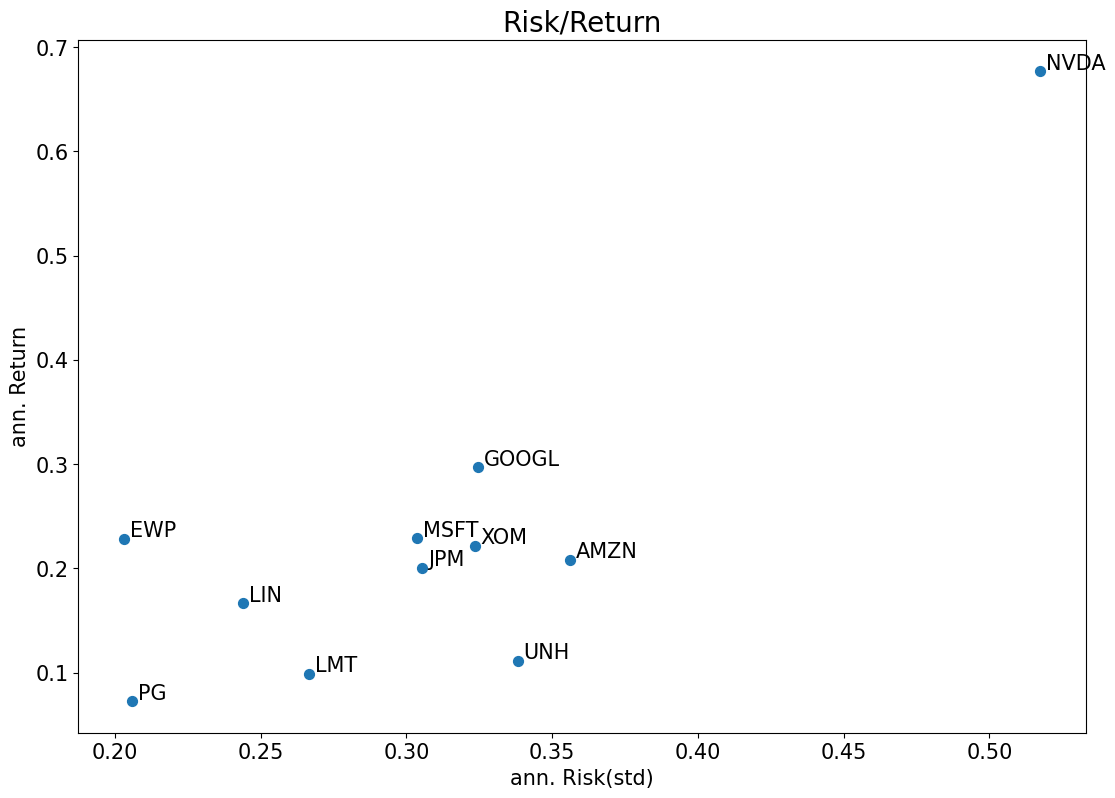

In [11]:
# Plotting Return and Risk for each individual stock
summary.plot(kind = "scatter", x = "Risk", y = "Return", figsize = (13,9), s = 50, fontsize = 15)
for i in summary.index:
    plt.annotate(i, xy = (summary.loc[i,"Risk"]+0.002 , summary.loc[i, "Return"]+0.002), size = 15)
plt.xlabel("ann. Risk(std)", fontsize = 15)
plt.ylabel("ann. Return", fontsize = 15)
plt.title("Risk/Return", fontsize = 20)
plt.show()

# Scenario 2: Random Portfolio Construction and Optimization

## Finding Optimal Weights

In [5]:
stocks

,AMZN,GOOGL,JPM,LIN,LMT,MSFT,NVDA,PG,UNH,XOM
Date,,,,,,,,,,
2020-01-02,94.9005,67.7889,117.8992,191.4998,333.3516,151.5442,5.9571,103.9593,260.1006,52.6064
2020-01-03,93.7485,67.4343,116.3433,186.5201,345.3461,149.6573,5.8618,103.2601,257.4684,52.1835
2020-01-06,95.1440,69.2317,116.2508,185.7296,344.8203,150.0441,5.8864,103.4033,259.2558,52.5841
2020-01-07,95.3430,69.0980,114.2745,186.1294,345.9805,148.6760,5.9576,102.7631,257.6907,52.1538
2020-01-08,94.5985,69.5898,115.1660,188.4557,343.0840,151.0442,5.9688,103.2011,263.1239,51.3673
...,...,...,...,...,...,...,...,...,...,...
2026-09-24,249.3800,342.3600,338.5600,468.1400,523.7000,497.9300,224.5800,145.6800,375.0100,162.1400
2026-09-25,249.6700,343.9200,343.0600,469.8900,519.5600,516.1700,225.0700,146.2300,376.5900,160.5900
2026-09-28,246.1500,342.7500,336.5900,472.0400,518.1000,509.2200,228.8600,149.0300,377.8300,162.5200


In [6]:
ret_2 = stocks.pct_change(fill_method = None).dropna()
ret_2

,AMZN,GOOGL,JPM,LIN,LMT,MSFT,NVDA,PG,UNH,XOM
Date,,,,,,,,,,
2020-01-03,-0.0121,-0.0052,-0.0132,-0.0260,0.0360,-0.0125,-0.0160,-0.0067,-0.0101,-0.0080
2020-01-06,0.0149,0.0267,-0.0008,-0.0042,-0.0015,0.0026,0.0042,0.0014,0.0069,0.0077
2020-01-07,0.0021,-0.0019,-0.0170,0.0022,0.0034,-0.0091,0.0121,-0.0062,-0.0060,-0.0082
2020-01-08,-0.0078,0.0071,0.0078,0.0125,-0.0084,0.0159,0.0019,0.0043,0.0211,-0.0151
2020-01-09,0.0048,0.0105,0.0037,0.0070,0.0095,0.0125,0.0110,0.0109,-0.0057,0.0077
...,...,...,...,...,...,...,...,...,...,...
2026-09-24,0.0004,0.0134,0.0031,-0.0034,-0.0019,-0.0053,-0.0041,-0.0116,0.0100,0.0056
2026-09-25,0.0012,0.0046,0.0133,0.0037,-0.0079,0.0366,0.0022,0.0038,0.0042,-0.0096
2026-09-28,-0.0141,-0.0034,-0.0189,0.0046,-0.0028,-0.0135,0.0168,0.0191,0.0033,0.0120


In [7]:
annual_ret = ret_2.mean(axis = 0)*252
annual_ret

AMZN    0.2080
GOOGL   0.2969
JPM     0.2007
LIN     0.1664
LMT     0.0991
MSFT    0.2290
NVDA    0.6769
PG      0.0725
UNH     0.1111
XOM     0.2217
dtype: float64

In [8]:
cov_matrix = ret_2.cov()
cov_matrix

,AMZN,GOOGL,JPM,LIN,LMT,MSFT,NVDA,PG,UNH,XOM
AMZN,0.0005,0.0003,0.0001,0.0001,0.0000,0.0003,0.0004,0.0001,0.0001,0.0000
GOOGL,0.0003,0.0004,0.0002,0.0001,0.0001,0.0002,0.0004,0.0001,0.0001,0.0001
JPM,0.0001,0.0002,0.0004,0.0002,0.0001,0.0001,0.0002,0.0001,0.0001,0.0002
LIN,0.0001,0.0001,0.0002,0.0002,0.0001,0.0001,0.0002,0.0001,0.0001,0.0001
LMT,0.0000,0.0001,0.0001,0.0001,0.0003,0.0001,0.0000,0.0001,0.0001,0.0001
MSFT,0.0003,0.0002,0.0001,0.0001,0.0001,0.0004,0.0004,0.0001,0.0001,0.0001
NVDA,0.0004,0.0004,0.0002,0.0002,0.0000,0.0004,0.0011,0.0001,0.0001,0.0001
PG,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0002,0.0001,0.0001
UNH,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0005,0.0001
XOM,0.0000,0.0001,0.0002,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0004


In [10]:
corr_matrix = ret_2.corr()
corr_matrix

,AMZN,GOOGL,JPM,LIN,LMT,MSFT,NVDA,PG,UNH,XOM
AMZN,1.000000,0.627617,0.287837,0.301782,0.092546,0.630591,0.547044,0.187599,0.163408,0.103955
GOOGL,0.627617,1.000000,0.382781,0.407042,0.156513,0.629569,0.543942,0.262367,0.252011,0.192092
JPM,0.287837,0.382781,1.000000,0.567024,0.346414,0.387900,0.329473,0.313544,0.340566,0.499329
LIN,0.301782,0.407042,0.567024,1.000000,0.338761,0.473970,0.396705,0.473673,0.380022,0.385878
LMT,0.092546,0.156513,0.346414,0.338761,1.000000,0.205265,0.088576,0.361350,0.314580,0.355945
MSFT,0.630591,0.629569,0.387900,0.473970,0.205265,1.000000,0.622236,0.326324,0.299080,0.190303
NVDA,0.547044,0.543942,0.329473,0.396705,0.088576,0.622236,1.000000,0.142920,0.199057,0.149280
PG,0.187599,0.262367,0.313544,0.473673,0.361350,0.326324,0.142920,1.000000,0.335896,0.193064
UNH,0.163408,0.252011,0.340566,0.380022,0.314580,0.299080,0.199057,0.335896,1.000000,0.246728
XOM,0.103955,0.192092,0.499329,0.385878,0.355945,0.190303,0.149280,0.193064,0.246728,1.000000


In [9]:
#Download risk free return from Yahoo Finance (13-week Treasury Bills)
risk_free_return = yf.download("^IRX", period = "5d", auto_adjust = True)
rf = risk_free_return["Close"]["^IRX"].iloc[-1] / 100

[*********************100%***********************]  1 of 1 completed


In [10]:
def standard_deviation ( weights, cov_matrix):
    """Compute annualized portfolio volatility"""
    return np.sqrt((weights @ cov_matrix @ weights.T)*252)
def expected_return (weights, annual_ret):
    """Compute annualized portfolio expected return"""
    return np.sum(weights * annual_ret)
def sharpe_ratio(weights, annual_ret, cov_matrix, rf):
    """Compute Sharpe Ratio = (expected return - rf) / standard_deviation"""
    return (expected_return(weights, annual_ret) - rf) / standard_deviation(weights, cov_matrix)
def negative_sharpe(weights, annual_ret, cov_matrix, rf):
    """Return negative Sharpe ratio so that minimize() will maximize Sharpe Ratio"""
    return -sharpe_ratio(weights, annual_ret, cov_matrix, rf)
# Constraints: weights must sum to 1 (fully invested portfolio)
constraints = ({"type": "eq",   "fun": lambda w: np.sum(w) - 1})
# Bounds: long-only portfolio (each weight between 0 and 1)
bounds = [(0, 1)] * len(annual_ret)
# Create initial weights
initial_weights = np.array([1/len(annual_ret)]* len(annual_ret))
from scipy.optimize import minimize
# Optimize to find the portfolio with maximum Sharpe Ratio
result = minimize(negative_sharpe, initial_weights, args = (annual_ret, cov_matrix, rf), method = "SLSQP", bounds = bounds, constraints = constraints)
# Extract optimal weights
opt_weights  = result.x
# Compute return, volatility, and Sharpe Ratio of the optimal portfolio
opt_ret = expected_return(opt_weights, annual_ret)
opt_vol = standard_deviation(opt_weights, cov_matrix)
opt_sharpe = sharpe_ratio(opt_weights, annual_ret, cov_matrix, rf)
tickers = annual_ret.index.tolist()
tickers
print("Optimal Weights: ")
for ticker, weight in zip(tickers, opt_weights):
    print(f"{ticker} : {weight:.4f}")
print(f"Expected Return: {opt_ret:.2%}")
print(f"Standard Deviation: {opt_vol:.2%}")
print(f"Sharpe Ratio:{opt_sharpe:.4f}")
# Allocation (Total value = 111000)
print("\nAllocation:")
for ticker, weight in zip(tickers, opt_weights):
    """Find number of shares to buy"""
    current_price = float(stocks[ticker].iloc[-1])
    shares = round((weight * 111000) / current_price)
    print(f"{ticker} : {shares:,.2f}")

Optimal Weights: 
AMZN : 0.0000
GOOGL : 0.0962
JPM : 0.0000
LIN : 0.0000
LMT : 0.0000
MSFT : 0.0000
NVDA : 0.5881
PG : 0.0000
UNH : 0.0000
XOM : 0.3157
Expected Return: 49.66%
Standard Deviation: 35.33%
Sharpe Ratio:1.2926

Allocation:
AMZN : 0.00
GOOGL : 31.00
JPM : 0.00
LIN : 0.00
LMT : 0.00
MSFT : 0.00
NVDA : 284.00
PG : 0.00
UNH : 0.00
XOM : 213.00


## Efficient Frontier Plotting

   Target Return Volatility  AMZN GOOGL   JPM   LIN    LMT  MSFT    NVDA  \
0          7.25%     20.60%  0.0%  0.0%  0.0%  0.0%   0.0%  0.0%    0.0%   
1          7.86%     18.93%  0.0%  0.0%  0.0%  0.0%  19.4%  0.0%    0.0%   
2          8.47%     18.34%  2.9%  0.0%  0.0%  0.0%  22.6%  0.0%    0.0%   
3          9.08%     17.94%  6.0%  0.0%  0.0%  0.9%  22.4%  0.0%    0.0%   
4          9.69%     17.61%  7.3%  0.0%  0.0%  2.6%  21.3%  0.0%    0.0%   
..           ...        ...   ...   ...   ...   ...    ...   ...     ...   
95        65.25%     49.25%  0.0%  0.0%  0.0%  0.0%   0.0%  0.0%   94.6%   
96        65.86%     49.87%  0.0%  0.0%  0.0%  0.0%   0.0%  0.0%   96.0%   
97        66.47%     50.49%  0.0%  0.0%  0.0%  0.0%   0.0%  0.0%   97.3%   
98        67.08%     51.11%  0.0%  0.0%  0.0%  0.0%   0.0%  0.0%   98.7%   
99        67.69%     51.74%  0.0%  0.0%  0.0%  0.0%   0.0%  0.0%  100.0%   

        PG   UNH   XOM  
0   100.0%  0.0%  0.0%  
1    78.1%  2.4%  0.0%  
2    68.5%  

<Figure size 1000x600 with 0 Axes>

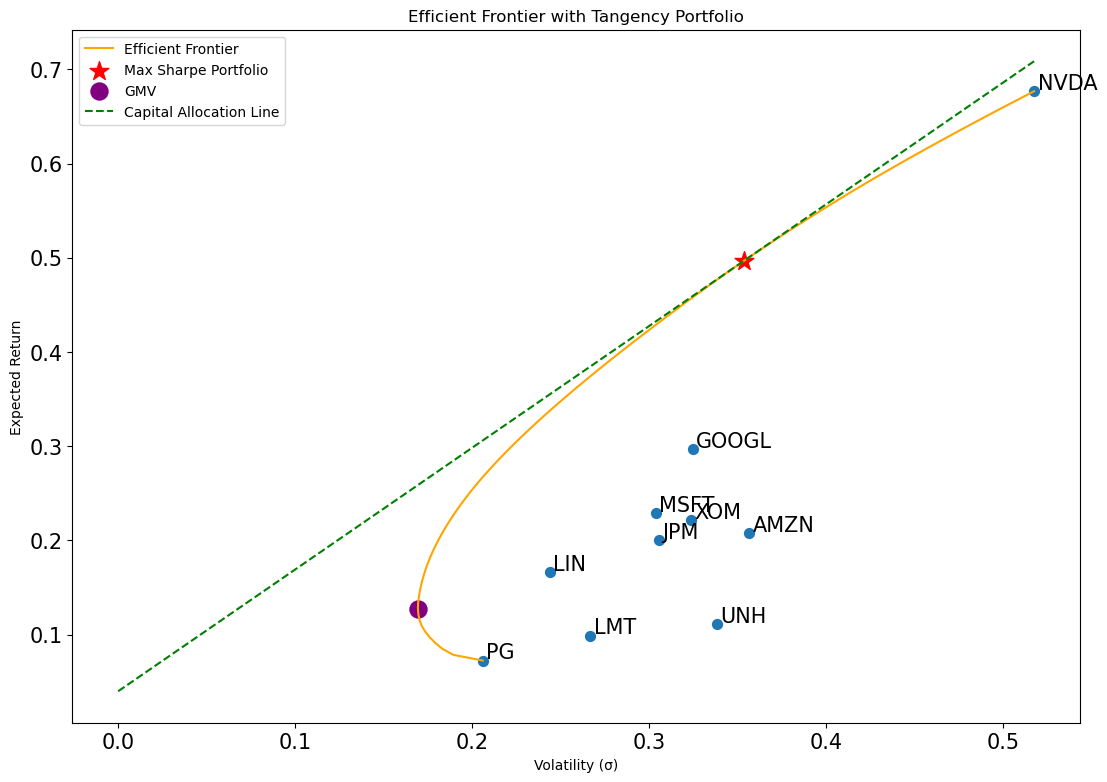

In [14]:
def minimize_volatility(target_return, annual_ret, cov_matrix, n_assets):
    def portfolio_vol(weights, cov_matrix):
        return np.sqrt((weights @ cov_matrix @ weights.T)*252)

    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: np.dot(w, annual_ret) - target_return}
    )
    bounds = tuple((0, 1) for _ in range(n_assets))
    initial_guess = np.array([1 / n_assets] * n_assets)

    min_vol = minimize(portfolio_vol, initial_guess, args=(cov_matrix,),
                       method='SLSQP', bounds=bounds, constraints=constraints)
    return min_vol

n_assets = len(tickers)
target_returns = np.linspace(annual_ret.min(), annual_ret.max(), 100)
frontier_volatility, frontier_weights = [], []

for target in target_returns:
    res = minimize_volatility(target, annual_ret, cov_matrix, n_assets)
    if res.success:
        frontier_volatility.append(res.fun)
        frontier_weights.append(res.x)
    else:
        frontier_volatility.append(np.nan)
        frontier_weights.append([np.nan]*n_assets)

frontier_df = pd.DataFrame(frontier_weights, columns=tickers)
frontier_df.insert(0, 'Target Return', target_returns)
frontier_df.insert(1, 'Volatility', frontier_volatility)

# --- Display ---
display_df = frontier_df.copy()
display_df['Target Return'] = display_df['Target Return'].map('{:.2%}'.format)
display_df['Volatility'] = display_df['Volatility'].map('{:.2%}'.format)
for t in tickers:
    display_df[t] = display_df[t].map('{:.1%}'.format)
print(display_df)
                                # --- Plot ---
plt.figure(figsize=(10,6))
# --- Displaying Stocks --- 
summary.plot(kind = "scatter", x = "Risk", y = "Return", figsize = (13,9), s = 50, fontsize = 15)
for i in summary.index:
    plt.annotate(i, xy = (summary.loc[i,"Risk"]+0.002 , summary.loc[i, "Return"]+0.002), size = 15)
# --- Plotting Efficient Frontier ---
plt.plot(frontier_volatility, target_returns, label='Efficient Frontier',color = 'orange')
# --- Displaying Tangency Portfolio (Max Sharpe) ---
plt.scatter(opt_vol, opt_ret, color='red', marker='*', s=200, label='Max Sharpe Portfolio')
# Plotting GMV
idx_gmv = frontier_df['Volatility'].idxmin()
gmv_vol = frontier_df.loc[idx_gmv, 'Volatility']
gmv_ret = frontier_df.loc[idx_gmv, 'Target Return']
plt.scatter(gmv_vol, gmv_ret, color = 'purple', marker = 'o', s = 150, label = 'GMV')
# Plotting CAL
cal_x = np.linspace(0, max(frontier_volatility), 100)
cal_y= rf + opt_sharpe * cal_x
plt.plot(cal_x, cal_y, color = "green", linestyle = '--', label = 'Capital Allocation Line')
plt.xlabel('Volatility (σ)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier with Tangency Portfolio')
plt.legend()
plt.show()